# Mini Flappy Bird - World Model
## Phase 1: Environment Setup & Unsupervised Rollout Collection
Architecture reference: Ha & Schmidhuber (World Models, 2018)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### 1. Lightweight Minimalist Flappy Bird Engine

In [2]:
class MiniFlappy:
    """Minimalist Flappy Bird environment with a 32x32 RGB canvas."""
    
    # 1. Canvas Dimensions
    SIZE = 32  # 32x32 resolution gives 3,072 float32 values per frame
    
    # 2. Color Palette (normalized float32 values [0.0, 1.0])
    BG_COLOR   = np.array([0.08, 0.08, 0.16], dtype=np.float32)  # Dark navy sky
    BIRD_COLOR = np.array([1.00, 1.00, 0.00], dtype=np.float32)  # High-contrast bright yellow
    PIPE_COLOR = np.array([0.10, 0.80, 0.25], dtype=np.float32)  # Vibrant green
    
    # 3. Bird Geometry
    BIRD_X = 8      # Bird is pinned horizontally at column 8
    BIRD_SIZE = 2   # 2x2 pixel footprint
    
    # 4. Pipe Geometry
    PIPE_WIDTH = 3
    GAP_SIZE = 9 

    # 5. Physics Constants
    GRAVITY = 0.3
    FLAP_STRENGTH = -1.2
    MAX_SPEED = 3.0

    def __init__(self, seed=None):
        self.rng = np.random.default_rng(seed)
        self.reset()
        
    def reset(self):
        self.t = 0
        self.bird_y = float(self.SIZE // 2)
        self.bird_vel = 0.0
        self.pipe_x = float(self.SIZE - 1)
        max_gap_y = self.SIZE - 4 - self.GAP_SIZE
        self.gap_y = self.rng.integers(4, max_gap_y + 1)
        return self.observe()

    def _spawn_pipe(self):
        """Spawns a new pipe with a random vertical gap."""
        self.pipe_x = float(self.SIZE - 1)
        max_gap_y = self.SIZE - 4 - self.GAP_SIZE
        self.gap_y = self.rng.integers(4, max_gap_y + 1)
        
    def update_pipe(self):
        """Scroll the pipe leftward by 1 pixel per time step."""
        self.pipe_x -= 1.0
        if self.pipe_x + self.PIPE_WIDTH <= 0:
            self._spawn_pipe()

    def update_bird(self, action):
        """Applies flap impulse (action=1) or gravity (action=0) and updates position."""
        if action == 1:
            self.bird_vel = self.FLAP_STRENGTH
            
        self.bird_vel = float(np.clip(self.bird_vel + self.GRAVITY, -self.MAX_SPEED, self.MAX_SPEED))
        self.bird_y += self.bird_vel

        # Floor and ceiling boundaries
        max_y = float(self.SIZE - self.BIRD_SIZE)
        if self.bird_y < 0.0:
            self.bird_y = 0.0
            self.bird_vel = 0.0
        elif self.bird_y > max_y:
            self.bird_y = max_y
            self.bird_vel = 0.0

    def step(self, action):
        """
        Advances the world by 1 frame given an action (0=fall, 1=flap).
        Returns: (next_observation, done)
        """
        self.update_bird(action)
        self.update_pipe()
        self.t += 1
        done = self.t >= 100
        return self.observe(), done

    def observe(self):
        """Renders current state into a (32, 32, 3) float32 RGB image."""
        # 1. Empty background sky
        frame = np.full((self.SIZE, self.SIZE, 3), self.BG_COLOR, dtype=np.float32)
        
        # 2. Render pipes
        px = int(round(self.pipe_x))
        x_start = max(0, px)
        x_end = min(self.SIZE, px + self.PIPE_WIDTH)

        if x_start < x_end:
            # Top pipe
            frame[0:self.gap_y, x_start:x_end] = self.PIPE_COLOR
            # Bottom pipe
            frame[self.gap_y + self.GAP_SIZE:self.SIZE, x_start:x_end] = self.PIPE_COLOR

        # 3. Render bird
        yi = int(round(self.bird_y))
        xi = int(self.BIRD_X)
        
        y_min = max(0, yi)
        y_max = min(self.SIZE, yi + self.BIRD_SIZE)
        x_min = max(0, xi)
        x_max = min(self.SIZE, xi + self.BIRD_SIZE)
        
        frame[y_min:y_max, x_min:x_max] = self.BIRD_COLOR
        return frame

### 2. Collect Unsupervised Rollouts (200 Episodes x 100 Steps)

In [3]:
EPISODES = 200
T = 100
SIZE = 32
SEED = 42

env = MiniFlappy(seed=SEED)
rng = np.random.default_rng(SEED)

# Pre-allocate memory for frames and actions
frames = np.zeros((EPISODES, T, SIZE, SIZE, 3), dtype=np.float32)
actions = np.zeros((EPISODES, T), dtype=np.int64)

print(f"Recording {EPISODES} episodes of {T} steps each...")

for e in range(EPISODES):
    obs = env.reset()
    for t in range(T):
        # Random policy: flap ~18% of the time, fall ~82% of the time
        a = 1 if (rng.random() < 0.18) else 0
        
        frames[e, t] = obs
        actions[e, t] = a
        
        obs, done = env.step(a)

print("Collection completed!")
print(f"Frames shape: {frames.shape} | Memory: {frames.nbytes / (1024 * 1024):.1f} MB")
print(f"Actions shape: {actions.shape}")

Recording 200 episodes of 100 steps each...
Collection completed!
Frames shape: (200, 100, 32, 32, 3) | Memory: 234.4 MB
Actions shape: (200, 100)


### 3. Verify Rollouts (Inspect Consecutive Frames)

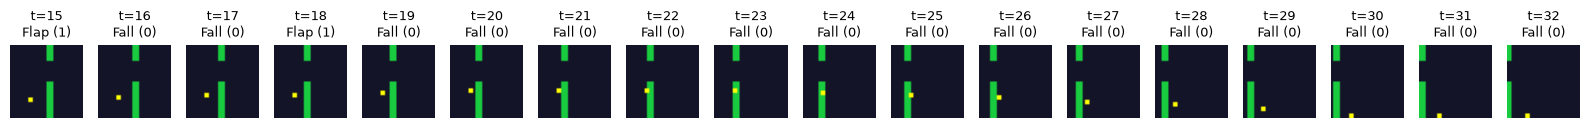

In [4]:
e_to_view = 10
start_step = 15
num_frames = 18

fig, axes = plt.subplots(1, num_frames, figsize=(16, 3))
for i in range(num_frames):
    t = start_step + i
    img = frames[e_to_view, t]
    act = actions[e_to_view, t]
    act_label = "Flap (1)" if act == 1 else "Fall (0)"
    
    axes[i].imshow(img)
    axes[i].set_title(f"t={t}\n{act_label}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 4. Prepare PyTorch Dataset for Vision Model (VAE)
Flatten (200 episodes, 100 steps) into 20,000 independent frames and convert to channel-first format: (N, C, H, W).

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert to torch tensor: (200, 100, 32, 32, 3) -> (20000, 32, 32, 3)
all_frames = torch.tensor(frames, dtype=torch.float32).reshape(-1, SIZE, SIZE, 3)
# Permute to PyTorch channel-first format: (N, H, W, C) -> (N, C, H, W)
all_frames = all_frames.permute(0, 3, 1, 2).contiguous()

print(f"Original NumPy shape: {frames.shape}")
print(f"PyTorch training tensor shape: {all_frames.shape} (N, C, H, W)")

Using device: cuda
Original NumPy shape: (200, 100, 32, 32, 3)
PyTorch training tensor shape: torch.Size([20000, 3, 32, 32]) (N, C, H, W)


--- 
## Phase 2: Vision Model (Variational Autoencoder)
Next step: Building the Encoder, Reparameterization Trick, Decoder, and Weighted Loss Function.

In [6]:
conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=4,stride=2,padding=1)



conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=4,stride=2,padding=1)

conv3 = nn.Conv2d(in_channels=64 ,out_channels=128,kernel_size=4,stride=2,padding=1)



In [7]:
dummy_image = torch.randn(1,3,32,32)
print("starting image shape at 0 : " , dummy_image.shape)




starting image shape at 0 :  torch.Size([1, 3, 32, 32])


In [8]:
## Passing through conv1

x1 = F.relu(conv1(dummy_image))
print(" shape after Conv 1 " , x1.shape)

 shape after Conv 1  torch.Size([1, 32, 16, 16])


In [9]:
x2 = F.relu(conv2(x1))
print("2. After Conv 2 shape:      ", x2.shape)

2. After Conv 2 shape:       torch.Size([1, 64, 8, 8])


In [10]:
x3 = F.relu(conv3(x2))
print(" 3 image shpae " , x3.shape)

 3 image shpae  torch.Size([1, 128, 4, 4])


In [11]:
LATENT_DIM = 32
fc_mu = nn.Linear(128*4*4, LATENT_DIM)
fc_logvar = nn.Linear(128*4*4,LATENT_DIM)

print("conv3 ouput shape ", x3.shape)
#  1. Flatten the conv3 output (x3 was shape [1, 128, 4, 4])
x_flat = x3.view(x3.size(0), -1)
print("Flattened shape: ", x_flat.shape) 






conv3 ouput shape  torch.Size([1, 128, 4, 4])
Flattened shape:  torch.Size([1, 2048])


In [12]:
fc_mu

Linear(in_features=2048, out_features=32, bias=True)

In [13]:
mu = fc_mu(x_flat)
logvar = fc_logvar(x_flat)

print("shpae of mu " , mu.shape)
print("shpae of mu " , logvar.shape)


shpae of mu  torch.Size([1, 32])
shpae of mu  torch.Size([1, 32])


In [14]:
# calculating sigma and sample noise
std = torch.exp(0.5 * logvar) # ---> log(sigma^2)
eps = torch.randn_like(std)

z = mu + std * eps
z

tensor([[ 2.5343,  0.0755, -1.6087,  1.1160,  0.3195,  0.4766, -0.5337, -0.3345,
          0.3628,  1.0160,  0.2473,  0.1290, -0.4760,  0.6138,  0.0339, -0.9381,
         -0.6270,  0.2194, -0.4953, -0.8605,  0.1885,  0.4862, -0.0716, -0.4807,
          1.2301, -1.6700,  0.0108,  1.6586,  0.3745, -0.7552,  1.5457,  0.8754]],
       grad_fn=<AddBackward0>)

In [15]:
print(" shape of Z ", z.shape)

 shape of Z  torch.Size([1, 32])


In [16]:
fc_dec = nn.Linear(LATENT_DIM,128*4*4)

## Transpoed Conv Layere(double spatial dimenstions each time )
decov1 = nn.ConvTranspose2d(128,64,kernel_size=4,stride=2,padding=1)
decov2 = nn.ConvTranspose2d(64,32,kernel_size=4,stride=2,padding=1)
decov3 = nn.ConvTranspose2d(32,3,kernel_size=4,stride=2,padding=1)


In [17]:
#  --- Decoder forward pass ---

d0 = fc_dec(z).view(z.size(0),128,4,4)
d0.shape

torch.Size([1, 128, 4, 4])

In [18]:
d1 = F.relu(decov1(d0))
d1.shape

torch.Size([1, 64, 8, 8])

In [19]:
d2 = F.relu(decov2(d1))
d2.shape

torch.Size([1, 32, 16, 16])

In [20]:
d3 = F.relu(decov3(d2))
d3.shape

torch.Size([1, 3, 32, 32])

In [ ]:
class VAE(nn.Module):
     def __init__(self,latent_dim = 32):
          super().__init__()

          """ we are initializing our work tool so that we do not have to initaliaing it again and agian 
          """



          ## encoder toolkit 
          self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
          self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
          self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
          
          
          ## Linear projection toolkit
          self.fc_mu = nn.Linear(128*4*4, latent_dim)
          self.fc_logvar = nn.Linear(128*4*4, latent_dim)

          ## Deocder toolkit 

          self.fc_dec = nn.Linear(latent_dim,128*4*4)
          self.deconv1 = nn.ConvTranspose2d(128,64,kernel_size=4,stride=2,padding=1)
          self.deconv2 = nn.ConvTranspose2d(64,32,kernel_size=4,stride=2,padding=1)
          self.deconv3 = nn.ConvTranspose2d(32,3,kernel_size=4,stride=2,padding=1)




          




          
          
          def encode(self, x):
                    """
                    INPUT : (N,3,32,32)
                    OUTPUT : (mu, logvar)

                    Variable : N: no of photo phased / Batch_size [ N = 64 ] for our project
                    funtion : we are compressing the photos to different convolutional layer

                              [64,3,32,32]
                                   │
                                   ▼ 
                              [64,32,32,32]
                                   │
                                   ▼ 
                              [64,64,32,32]
                                   │
                                   ▼ 
                              [64,128,32,32]
                                   │
                                   ▼ 
                              [ mu,logvar]
                    
                    
                    
                    """



          def reparameterize(x):
                    """
                    INPUT : [mu , logvar]    
                    OUTPUT: z

                    Variable: 
                    function: CALCULATES (Z)
                    
                    
                    
                    
                    std = torch.exp(0.5 * logvar) # ---> log(sigma^2)
                    eps = random sample form normal distribution (0,1)

                    z = mu + std * eps

                    


                    
                    
                    """




          def decode(x):
               """ 
               INPUT : z
               OUTPUT : (N,3,32,32) // complete photo reconstructed


               Variable : z,N
               functions : reconstructed alomost the identical photo form latent variable (z )
                              [N,128,32,32]
                                   │
                                   ▼ 
                              [N,64,32,32]
                                   │
                                   ▼ 
                              [N,32,32,32]
                                   │
                                   ▼ 
                              [N,16,32,32]
                                   │
                                   ▼
                              (N,3,32,32)
               """



               def forward(x):

                    """
                    
                         INPUT: takes all the forward founction 
                         1.  encode(x)
                         2.  decode(x)
                         3. reparameterazed(x)


                         Ouput : z

                         fucntion : does all the forward pass of convalution by wraping all the three function in one single step 
                         and returns the [z] value 


                    
                    
                    
                    """

